In [186]:
import numpy as np
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import mnist
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout, Conv2D, MaxPool2D, Flatten
from sklearn.metrics import confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

## Loading and pre-processing

In [187]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

### Data Augmentation

In order to increase the model flexibility, we change the digits a bit

In [189]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
datagen.fit(x_train)

In [190]:
print(x_train.shape)

(60000, 28, 28, 1)


## Model creation

In [212]:
model = Sequential([
    Conv2D(filters=64, kernel_size=3, padding="same", activation="relu", input_shape=[28,28,1]),
    Conv2D(filters=64, kernel_size=3, padding="same", activation="relu"),
    MaxPool2D(pool_size=(2,2)),
    Dropout(0.25),
    Conv2D(filters=128, kernel_size=3, padding="same", activation="relu"),
    Conv2D(filters=128, kernel_size=3, padding="same", activation="relu"),
    MaxPool2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/home/carlos/projects/ai/python-env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,063,242 (4.06 MB)

 Trainable params: 1,063,242 (4.06 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [ ]:
# early stopping prevents unnecessary epochs when we already found the best results
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# do the training
trained_model = model.fit(datagen.flow(x_train, y_train, batch_size=32), epochs=10, validation_data=(x_test, y_test), callbacks=[early_stop])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 175s 92ms/step - accuracy: 0.9084 - loss: 0.2958 - val_accuracy: 0.9898 - val_loss: 0.0337
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 261s 139ms/step - accuracy: 0.9696 - loss: 0.1080 - val_accuracy: 0.9913 - val_loss: 0.0262
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 246s 131ms/step - accuracy: 0.9781 - loss: 0.0792 - val_accuracy: 0.9945 - val_loss: 0.0191
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 161s 86ms/step - accuracy: 0.9811 - loss: 0.0685 - val_accuracy: 0.9945 - val_loss: 0.0189
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 155s 83ms/step - accuracy: 0.9839 - loss: 0.0582 - val_accuracy: 0.9945 - val_loss: 0.0182
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 154s 82ms/step - accuracy: 0.9848 - loss: 0.0551 - val_accuracy: 0.9933 - val_loss: 0.0221
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 151s 80ms/step - accuracy: 0.9859 - loss: 0.0505 - val_accuracy: 0.9939 - val_loss: 0.0202
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 152s 81ms/step - accuracy

## Prediction

Loss and accuracy are calculated, as well as a confusion matrix

In [214]:
# prediction will return probabilities
y_pred_probs = model.predict(x_test)

# Convert probabilities (class with higher probability)
y_pred = np.argmax(y_pred_probs, axis=1)

loss, accuracy = model.evaluate(x_test, y_test)

print("Accuracy: " + str(accuracy))
print("Loss: "  +str(loss))

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9946 - loss: 0.0156
Accuracy: 0.9945999979972839
Loss: 0.015628531575202942


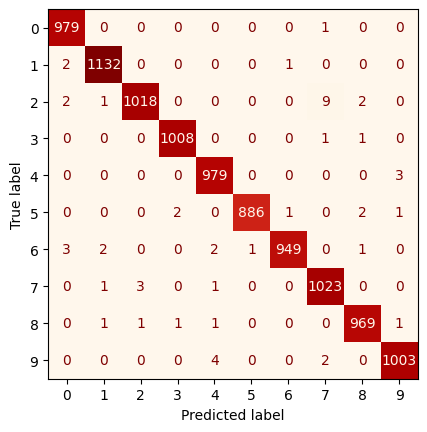

In [215]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot confusion matrix with correct labels
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='OrRd',
    colorbar=False
)

## Extra testing

Just for fun, we load an additional file with a manually drawn digit, just to check how good the model is at predicting its value.

In [ ]:
from PIL import Image

# carregar imagem
img = Image.open("digit.png").convert("L")  # grayscale

# redimensionar para 28x28
img = img.resize((28, 28))

# converter para array
img_array = np.asarray(img, dtype=np.float32)

# normalizar
img_array = img_array / 255.0

# garantir tipo float32
img_array = img_array.astype("float32")

# adicionar dimensões
img_array = np.expand_dims(img_array, axis=-1)  # canal
img_array = np.expand_dims(img_array, axis=0)   # batch

In [251]:

prediction = model(img_array, training=False)

probs = prediction.numpy()[0]
for i, p in enumerate(probs):
    print(f"{i}: {p*100:.2f}%")
digit = np.argmax(prediction)

print("Predicted digit:", digit)

0: 0.00%
1: 0.00%
2: 0.00%
3: 0.00%
4: 0.13%
5: 0.00%
6: 0.00%
7: 0.02%
8: 0.01%
9: 99.83%
Predicted digit: 9


In [219]:
import os

DATA_DIR = "digits"

X_custom = []
y_custom = []

for file in os.listdir(DATA_DIR):
    if file.endswith(".npy"):
        label = int(file.split("_")[0])

        img = np.load(os.path.join(DATA_DIR, file))

        X_custom.append(img)
        y_custom.append(label)

X_custom = np.array(X_custom)
y_custom = np.array(y_custom)

# adicionar canal (CNN)
X_custom = np.expand_dims(X_custom, axis=-1)

print(X_custom.shape, y_custom.shape)

(1, 28, 28, 1) (1,)


In [220]:
X_custom = np.repeat(X_custom, 5, axis=0)
y_custom = np.repeat(y_custom, 5, axis=0)

In [221]:
model.fit(
    X_custom,
    y_custom,
    epochs=3,
    batch_size=16
)

Epoch 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 16.4780
Epoch 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.0000e+00 - loss: 4.5471
Epoch 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 1.0000 - loss: 0.0679
